In [1]:
from datasets import load_dataset

In [2]:
ds = load_dataset("Ayush-Singh/cwv-bench-v0")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/813 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.11M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2976 [00:00<?, ? examples/s]

In [3]:
ds['train'][0]

{'repo_id': '879479119/879479119.github.io',
 'repo_name': '879479119.github.io',
 'framework': 'Hexo',
 'source': 'GH-25',
 'is_live': True,
 'site_status': 200,
 'site_error': None,
 'repo_url': None,
 'checked_url': 'https://879479119.github.io',
 'file_size_avg': 12713.860465116279,
 'total_file_size': 546696,
 'files': [{'language': 'HTML', 'length_bytes': 44209, 'path': '/index.html'},
  {'language': 'JavaScript', 'length_bytes': 3838, 'path': '/js/script.js'},
  {'language': 'JavaScript',
   'length_bytes': 48730,
   'path': '/fancybox/jquery.fancybox.js'},
  {'language': 'CSS',
   'length_bytes': 4863,
   'path': '/fancybox/jquery.fancybox.css'},
  {'language': 'JavaScript',
   'length_bytes': 23187,
   'path': '/fancybox/jquery.fancybox.pack.js'},
  {'language': 'HTML', 'length_bytes': 8077, 'path': '/archives/index.html'},
  {'language': 'CSS', 'length_bytes': 24597, 'path': '/css/style.css'},
  {'language': 'HTML',
   'length_bytes': 15431,
   'path': '/2017/02/07/17年1月开发小记/

# Task
Analyze the 'Ayush-Singh/cwv-bench-v0' dataset by extracting file sizes and languages from the 'files' field, calculating descriptive statistics for file sizes, determining the frequency and percentage of each programming language, and visualizing both the language and file size distributions, finally summarizing the key findings.

## Prepare Data for Analysis

### Subtask:
Extract all file sizes ('length_bytes') and language types ('language') from the 'files' field for each entry in the dataset and organize them into a pandas DataFrame for easier analysis.


**Reasoning**:
To prepare the data for analysis as requested, I will first initialize two empty lists to store the extracted file sizes and languages. Then, I will iterate through the dataset to populate these lists with the relevant information.



In [4]:
file_sizes = []
languages = []

# Iterate through each entry in the 'train' split of the dataset
for entry in ds['train']:
    # Access the 'files' field
    if 'files' in entry and entry['files'] is not None:
        # Iterate through each file dictionary in the 'files' list
        for file_data in entry['files']:
            # Extract 'length_bytes' and 'language' and append to lists
            if 'length_bytes' in file_data:
                file_sizes.append(file_data['length_bytes'])
            if 'language' in file_data:
                languages.append(file_data['language'])

print(f"Extracted {len(file_sizes)} file sizes and {len(languages)} languages.")

Extracted 263214 file sizes and 263214 languages.


**Reasoning**:
Now that the file sizes and languages have been extracted into separate lists, I will create a pandas DataFrame from these lists to organize the data for easier analysis, as specified in the subtask.



In [5]:
import pandas as pd

df_files = pd.DataFrame({
    'file_size': file_sizes,
    'language': languages
})

print("DataFrame created successfully.")
print(df_files.head())

DataFrame created successfully.
   file_size    language
0      44209        HTML
1       3838  JavaScript
2      48730  JavaScript
3       4863         CSS
4      23187  JavaScript


## Calculate Overall File Size Statistics

### Subtask:
Compute descriptive statistics such as total, average, median, minimum, maximum, and standard deviation for all extracted file sizes.


**Reasoning**:
To address the subtask, I will compute the total, average, median, minimum, maximum, and standard deviation of the 'file_size' column from the `df_files` DataFrame, and then print these statistics.



In [6]:
total_file_size = df_files['file_size'].sum()
average_file_size = df_files['file_size'].mean()
median_file_size = df_files['file_size'].median()
min_file_size = df_files['file_size'].min()
max_file_size = df_files['file_size'].max()
std_dev_file_size = df_files['file_size'].std()

print(f"Total File Size: {total_file_size} bytes")
print(f"Average File Size: {average_file_size:.2f} bytes")
print(f"Median File Size: {median_file_size} bytes")
print(f"Minimum File Size: {min_file_size} bytes")
print(f"Maximum File Size: {max_file_size} bytes")
print(f"Standard Deviation of File Size: {std_dev_file_size:.2f} bytes")

Total File Size: 6541934655 bytes
Average File Size: 24854.05 bytes
Median File Size: 5897.0 bytes
Minimum File Size: 9 bytes
Maximum File Size: 6452173 bytes
Standard Deviation of File Size: 114281.53 bytes


## Analyze Language Distribution

### Subtask:
Determine the frequency and percentage of each unique programming language found across all files in the dataset.


**Reasoning**:
To determine the frequency and percentage of each unique programming language, I will use the `value_counts()` method on the 'language' column of the `df_files` DataFrame. Then, I will calculate percentages by dividing the counts by the total number of languages and multiplying by 100. Finally, I will print both the counts and percentages.



In [7]:
language_counts = df_files['language'].value_counts()
language_percentages = (df_files['language'].value_counts() / len(df_files)) * 100

print("Language Frequencies:")
print(language_counts)
print("\nLanguage Percentages:")
print(language_percentages.round(2))

Language Frequencies:
language
HTML          133554
JavaScript     91655
Other           8061
CSS             7671
SCSS            4033
               ...  
Awk                1
TSQL               1
Haml               1
Nginx              1
fish               1
Name: count, Length: 127, dtype: int64

Language Percentages:
language
HTML          50.74
JavaScript    34.82
Other          3.06
CSS            2.91
SCSS           1.53
              ...  
Awk            0.00
TSQL           0.00
Haml           0.00
Nginx          0.00
fish           0.00
Name: count, Length: 127, dtype: float64


## Visualize Language Distribution

### Subtask:
Generate a bar chart to display the distribution of programming languages, with each bar representing a language and its height corresponding to its frequency or proportion. The plot will include appropriate labels and a legend.


**Reasoning**:
To visualize the language distribution, I will use `matplotlib.pyplot` and `seaborn` to create a bar chart based on the `language_counts` Series, displaying the top languages and adding appropriate labels and a title for clarity.



/tmp/ipython-input-1285749944.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts_top_n.index, y=language_counts_top_n.values, palette='viridis')


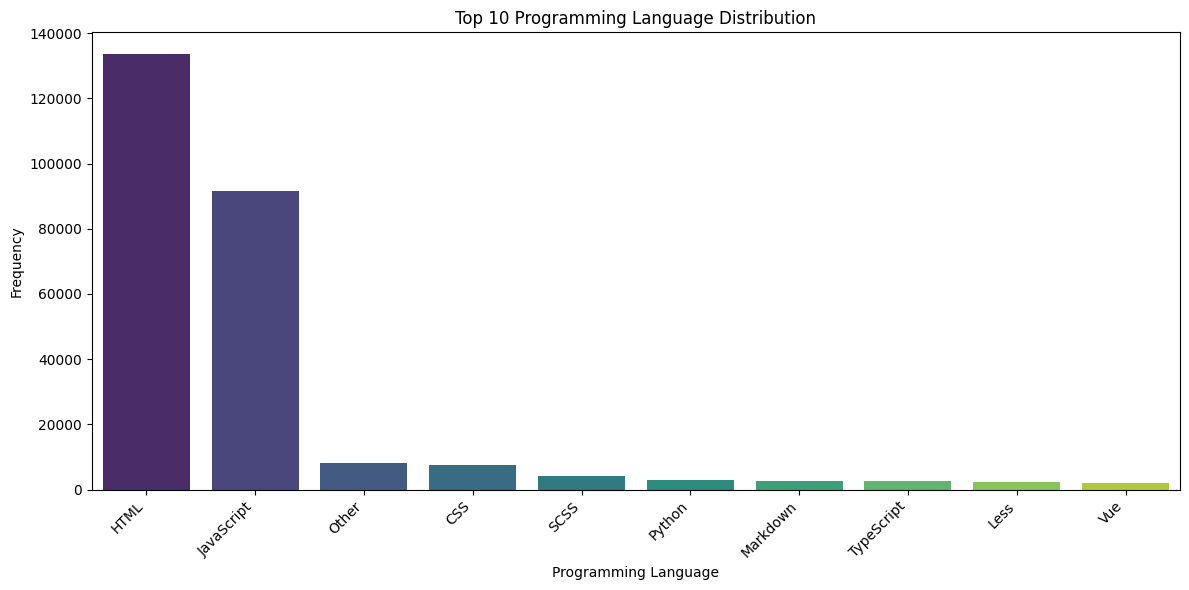

Bar chart showing the top 10 programming language distributions has been generated.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 10 languages for better readability
top_n = 10
language_counts_top_n = language_counts.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(x=language_counts_top_n.index, y=language_counts_top_n.values, palette='viridis')
plt.title(f'Top {top_n} Programming Language Distribution')
plt.xlabel('Programming Language')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Bar chart showing the top {top_n} programming language distributions has been generated.")

**Reasoning**:
The previous code generated a FutureWarning because `palette` was used without assigning a `hue` variable. To fix this and follow the recommended practice for seaborn v0.14.0+, I will explicitly assign the `x` variable to `hue` and set `legend=False` in the `sns.barplot` call.



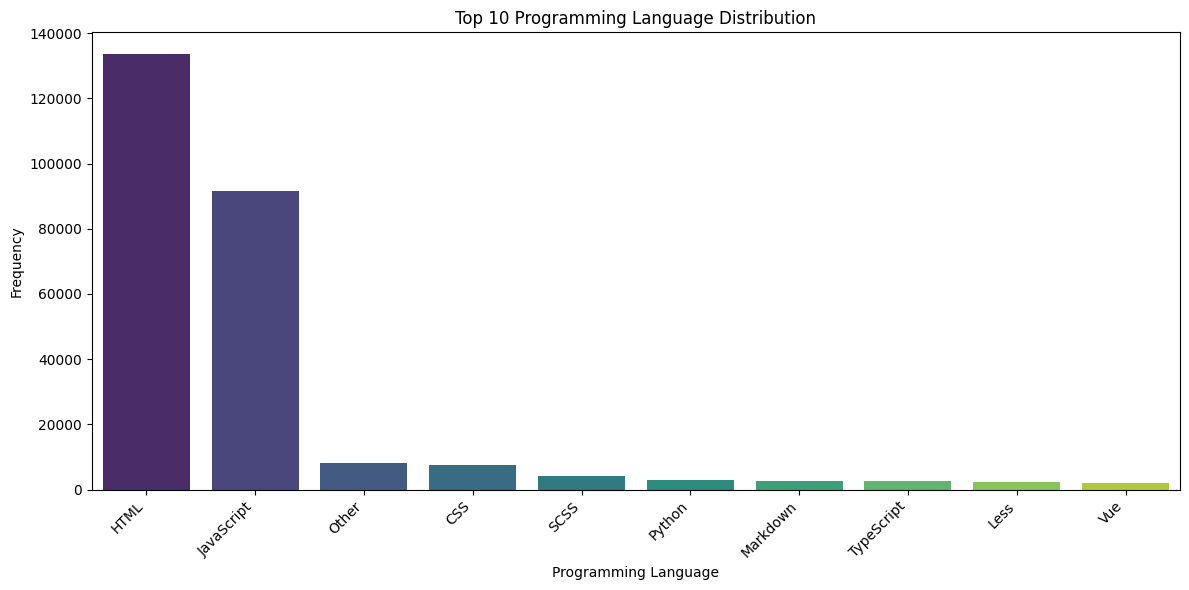

Bar chart showing the top 10 programming language distributions has been generated.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the top 10 languages for better readability
top_n = 10
language_counts_top_n = language_counts.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(x=language_counts_top_n.index, y=language_counts_top_n.values, hue=language_counts_top_n.index, palette='viridis', legend=False)
plt.title(f'Top {top_n} Programming Language Distribution')
plt.xlabel('Programming Language')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Bar chart showing the top {top_n} programming language distributions has been generated.")

## Visualize File Size Distribution

### Subtask:
Create a histogram or box plot to visualize the distribution of file sizes (in bytes). The plot will include appropriate labels and a legend.


**Reasoning**:
To visualize the distribution of file sizes, I will create a histogram using `matplotlib.pyplot` and `seaborn`, as requested in the instructions, specifying the 'file_size' column from `df_files` and adding appropriate labels and title.



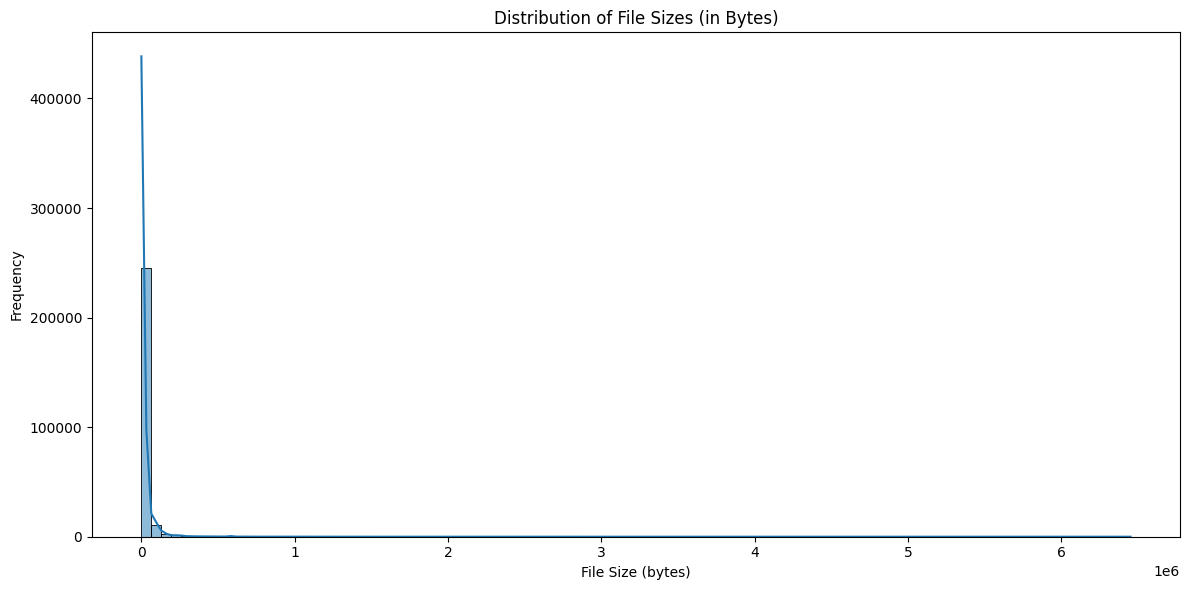

Histogram showing the distribution of file sizes has been generated.


In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df_files['file_size'], bins=100, kde=True)
plt.title('Distribution of File Sizes (in Bytes)')
plt.xlabel('File Size (bytes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histogram showing the distribution of file sizes has been generated.")

## Final Task

### Subtask:
Summarize the key findings from the file size statistics and language distribution analysis, providing insights into the dataset's characteristics.


## Summary:

### Data Analysis Key Findings

*   **File Extraction**: A total of 263,214 file sizes and corresponding languages were successfully extracted from the dataset.
*   **Overall File Size Statistics**:
    *   The total size of all files is approximately 6.54 GB (6,541,934,655 bytes).
    *   The average file size is 24,854.05 bytes, while the median file size is significantly smaller at 5,897.0 bytes. This large discrepancy indicates a skewed distribution, with many small files and a few very large files.
    *   File sizes range from a minimum of 9 bytes to a maximum of 6,452,173 bytes.
    *   The standard deviation of file size is 114,281.53 bytes, further emphasizing the wide spread and variability in file sizes.
*   **Language Distribution**:
    *   The dataset contains 127 unique programming languages.
    *   HTML is the most dominant language, accounting for 50.74% (133,554 occurrences) of all files.
    *   JavaScript is the second most common, comprising 34.82% (91,655 occurrences) of files.
    *   'Other' languages collectively represent 3.06% (8,061 occurrences), followed by CSS at 2.91% (7,671 occurrences).
    *   A significant number of languages have very low frequencies, with many appearing only once.
*   **Visualizations**: Bar charts were generated to visualize the top 10 language distributions, and a histogram with KDE was created to show the distribution of file sizes, confirming the aforementioned patterns.

### Insights or Next Steps

*   **Focus on Web Technologies**: Given that HTML, JavaScript, and CSS collectively represent over 88% of the files, the dataset appears to be heavily skewed towards web development projects. Further analysis could investigate the specific types of web projects or frameworks most prevalent.
*   **Handle File Size Skewness**: The highly skewed file size distribution (median is much lower than average) suggests that analytical methods robust to outliers, or transformations like logarithmic scaling, might be necessary for more accurate modeling or deeper insights into file size characteristics.
